In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
# https://drive.google.com/file/d/1jX2LqnhZZ-1gVcbWG8KRwTyTWtm95n6J/view?usp=sharing
# https://drive.google.com/file/d/1m9Y0xdvWvkSoiNC1vj2awqyMuC14ALst/view?usp=sharing
flie_id = "1m9Y0xdvWvkSoiNC1vj2awqyMuC14ALst"
flie_id2 = "1jX2LqnhZZ-1gVcbWG8KRwTyTWtm95n6J"
url = f"https://drive.google.com/uc?id={flie_id}"
url2 = f"https://drive.google.com/uc?id={flie_id2}"

df = pd.read_csv(url)
df2 = pd.read_csv(url2)

test = pd.read_csv(url)
training = pd.read_csv(url2)

df2.head(10)

Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
training.replace("?", np.nan, inplace = True)
df2.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
significant_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked','Survived']
df_selected = training[significant_features]
df_selected.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0
5,3,male,NaN,0,0,8.4583,Q,0
6,1,male,54.0,0,0,51.8625,S,0
7,3,male,2.0,3,1,21.0750,S,0
8,3,female,27.0,0,2,11.1333,S,1
9,2,female,14.0,1,0,30.0708,C,1


In [5]:
sex_mapping = {'male': 0, 'female': 1}
df_selected['Sex'] = df_selected['Sex'].map(sex_mapping)
display(df_selected.head())

/tmp/ipykernel_6872/3859629819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Sex'] = df_selected['Sex'].map(sex_mapping)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,0,22.0,1,0,7.2500,S,0
1,1,1,38.0,1,0,71.2833,C,1
2,3,1,26.0,0,0,7.9250,S,1
3,1,1,35.0,1,0,53.1000,S,1
4,3,0,35.0,0,0,8.0500,S,0


In [6]:
df_selected = pd.get_dummies(df_selected, columns=['Embarked'], prefix='Embarked')
display(df_selected.head())

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,0,False,False,True
1,1,1,38.0,1,0,71.2833,1,True,False,False
2,3,1,26.0,0,0,7.9250,1,False,False,True
3,1,1,35.0,1,0,53.1000,1,False,False,True
4,3,0,35.0,0,0,8.0500,0,False,False,True


In [7]:
target_variable_new = training['Survived']
display(target_variable_new.head())

,Survived
0,0
1,1
2,1
3,1
4,0


In [8]:
X = df_selected[['Pclass','Sex','SibSp','Parch','Fare','Embarked_C','Embarked_Q','Embarked_S']]
y = df_selected[['Survived']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## ¿Por qué escalar en KNN y SVM?

### KNN (K-Nearest Neighbors)
- Este algoritmo clasifica o predice basándose en la **distancia** entre los puntos de datos.
- Si las características tienen escalas muy diferentes (por ejemplo, `Edad` de 0 a 100 y `Salario` de 0 a 100,000), la característica con el rango más grande (`Salario`) dominará el cálculo de la distancia.
- Esto hace que las características con rangos más pequeños sean insignificantes.
- **El escalamiento asegura que todas las características contribuyan equitativamente al cálculo de la distancia.**

### SVM (Support Vector Machines)
- El objetivo de SVM es encontrar un **hiperplano óptimo** que separe las clases.
- La efectividad de este hiperplano está muy influenciada por la escala de las características.
- Características con valores más grandes pueden influir desproporcionadamente en la función de costo, lo que puede llevar a:
  - Un hiperplano subóptimo.
  - Un entrenamiento más lento.
- **El escalamiento ayuda a que el algoritmo converja más rápido y encuentre un mejor límite de decisión.**

---

## ¿Por qué NO es necesario escalar en árboles (Decision Trees, Random Forests, Gradient Boosting, etc.)?

- Los algoritmos basados en árboles toman decisiones **dividiendo los datos en función de umbrales en las características**.
- Por ejemplo, un árbol podría preguntar:  
  *"¿Edad > 30?"* o *"¿Salario > 50000?"*.
- La escala de la característica **no afecta** la capacidad del árbol para encontrar el mejor punto de división.
- Un umbral en `Edad` (como 30) o en `Salario` (como 50000) funciona igual de bien independientemente de si los datos están escalados o no.
- Esto se debe a que la decisión se basa en la **relación de orden** de los valores, **no en la distancia absoluta** entre ellos.
- **Conclusión:** El escalamiento de características **no mejora el rendimiento** de estos modelos.

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((623, 8), (268, 8), (623, 1), (268, 1))

In [10]:
knn5 = KNeighborsClassifier(n_neighbors = 5)

knn5.fit(X_train, y_train)

print("Precision del clasificador en fase de entrenamiento", knn5.score(X_train, y_train) )

Precision del clasificador en fase de entrenamiento 0.8282504012841091


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [11]:
y_pred = knn5.predict(X_test)
print("\nReporte de métricas del clasificador con 5 vecinos: \n",
classification_report(y_test, y_pred, target_names=["No Pagado", "Pagado"]))
print(f'\nMatriz de Confusion con 5 vecinos:\n', confusion_matrix(y_test, y_pred ))


Reporte de métricas del clasificador con 5 vecinos: 
               precision    recall  f1-score   support

   No Pagado       0.77      0.85      0.81       157
      Pagado       0.75      0.63      0.69       111

    accuracy                           0.76       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.76      0.76      0.76       268


Matriz de Confusion con 5 vecinos:
 [[134  23]
 [ 41  70]]


--- Reporte de Clasificación (KNN) ---
              precision    recall  f1-score   support

   No Pagado       0.77      0.85      0.81       157
      Pagado       0.75      0.63      0.69       111

    accuracy                           0.76       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.76      0.76      0.76       268


--- Matriz de Confusión (KNN) ---


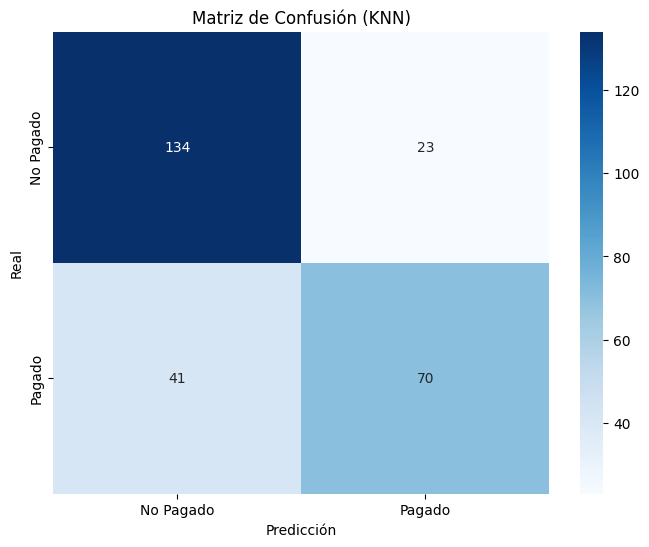


--- Interpretación de Métricas Clave (KNN) ---

Accuracy: 0.76
  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.

Precision (No Pagado): 0.77
  - De todas las veces que el modelo predijo 'No Pagado', ¿cuántas fueron realmente 'No Pagado'?
Precision (Pagado): 0.75
  - De todas las veces que el modelo predijo 'Pagado', ¿cuántas fueron realmente 'Pagado'?

Recall (No Pagado): 0.85
  - De todos los casos que *realmente* eran 'No Pagado', ¿cuántos fueron correctamente identificados por el modelo?
Recall (Pagado): 0.63
  - De todos los casos que *realmente* eran 'Pagado', ¿cuántos fueron correctamente identificados por el modelo?

F1-score (No Pagado): 0.81
  - Es la media armónica de la precisión y el recall para la clase 'No Pagado'. Ofrece un equilibrio entre ambas métricas.
F1-score (Pagado): 0.69
  - Es la media armónica de la precisión y el recall para la clase 'Pagado'.

**Consideraciones Adicionales:**
  - Si 

In [12]:
# Generate the classification report
report = classification_report(y_test, y_pred, target_names=["No Pagado", "Pagado"], output_dict=True)

print("--- Reporte de Clasificación (KNN) ---")
print(classification_report(y_test, y_pred, target_names=["No Pagado", "Pagado"]))

# Generate the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'\n--- Matriz de Confusión (KNN) ---')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Pagado", "Pagado"],
            yticklabels=["No Pagado", "Pagado"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (KNN)')
plt.show()

print("\n--- Interpretación de Métricas Clave (KNN) ---")

# Accuracy
accuracy = report['accuracy']
print(f"\nAccuracy: {accuracy:.2f}")
print("  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.")

# Precision
precision_no_pagado = report['No Pagado']['precision']
precision_pagado = report['Pagado']['precision']
print(f"\nPrecision (No Pagado): {precision_no_pagado:.2f}")
print("  - De todas las veces que el modelo predijo 'No Pagado', ¿cuántas fueron realmente 'No Pagado'?")
print(f"Precision (Pagado): {precision_pagado:.2f}")
print("  - De todas las veces que el modelo predijo 'Pagado', ¿cuántas fueron realmente 'Pagado'?")

# Recall (Sensibilidad)
recall_no_pagado = report['No Pagado']['recall']
recall_pagado = report['Pagado']['recall']
print(f"\nRecall (No Pagado): {recall_no_pagado:.2f}")
print("  - De todos los casos que *realmente* eran 'No Pagado', ¿cuántos fueron correctamente identificados por el modelo?")
print(f"Recall (Pagado): {recall_pagado:.2f}")
print("  - De todos los casos que *realmente* eran 'Pagado', ¿cuántos fueron correctamente identificados por el modelo?")

# F1-score
f1_no_pagado = report['No Pagado']['f1-score']
f1_pagado = report['Pagado']['f1-score']
print(f"\nF1-score (No Pagado): {f1_no_pagado:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'No Pagado'. Ofrece un equilibrio entre ambas métricas.")
print(f"F1-score (Pagado): {f1_pagado:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'Pagado'.")

print("\n**Consideraciones Adicionales:**")
print("  - Si el Recall para 'Pagado' (o 'Sobrevivió' en un contexto de Titanic) es bajo, significa que el modelo está perdiendo a muchas personas que realmente sobrevivieron (Falsos Negativos).")
print("  - Si la Precision para 'Pagado' es baja, significa que muchas de las predicciones de 'Pagado' son incorrectas (Falsos Positivos).")
print("  - La importancia de cada métrica (Precision vs. Recall) depende del problema de negocio y del costo asociado a los Falsos Positivos y Falsos Negativos.")

Precisión del clasificador en fase de entrenamiento (Regresión Logística): 0.7993579454253612

--- Reporte de Clasificación (Regresión Logística) ---
               precision    recall  f1-score   support

No Sobrevivió       0.81      0.81      0.81       157
   Sobrevivió       0.73      0.73      0.73       111

     accuracy                           0.78       268
    macro avg       0.77      0.77      0.77       268
 weighted avg       0.78      0.78      0.78       268


--- Matriz de Confusión (Regresión Logística) ---


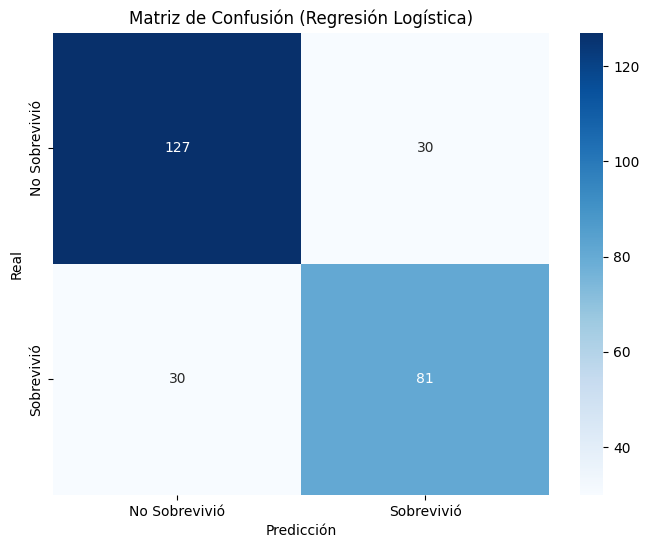


--- Interpretación de Métricas Clave (Regresión Logística) ---

Accuracy: 0.78
  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.

Precision (No Sobrevivió): 0.81
  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?
Precision (Sobrevivió): 0.73
  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?

Recall (No Sobrevivió): 0.81
  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?
Recall (Sobrevivió): 0.73
  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?

F1-score (No Sobrevivió): 0.81
  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.
F1-score (Sobrevivió): 0.73
  - Es la media armónica de la precisión y el reca

In [13]:
logreg = LogisticRegression(solver='liblinear', random_state=42)

# Entrenar el modelo
logreg.fit(X_train, y_train.values.ravel())

print("Precisión del clasificador en fase de entrenamiento (Regresión Logística):", logreg.score(X_train, y_train))

# Realizar predicciones sobre el conjunto de prueba
y_pred_logreg = logreg.predict(X_test)

# Generar el reporte de clasificación
report_logreg = classification_report(y_test, y_pred_logreg, target_names=["No Sobrevivió", "Sobrevivió"], output_dict=True)

print("\n--- Reporte de Clasificación (Regresión Logística) ---")
print(classification_report(y_test, y_pred_logreg, target_names=["No Sobrevivió", "Sobrevivió"]))

# Generar la Matriz de Confusión
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
print(f'\n--- Matriz de Confusión (Regresión Logística) ---')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Sobrevivió", "Sobrevivió"],
            yticklabels=["No Sobrevivió", "Sobrevivió"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.show()

print("\n--- Interpretación de Métricas Clave (Regresión Logística) ---")

# Accuracy
accuracy_logreg = report_logreg['accuracy']
print(f"\nAccuracy: {accuracy_logreg:.2f}")
print("  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.")

# Precision
precision_no_sobrevivio_logreg = report_logreg['No Sobrevivió']['precision']
precision_sobrevivio_logreg = report_logreg['Sobrevivió']['precision']
print(f"\nPrecision (No Sobrevivió): {precision_no_sobrevivio_logreg:.2f}")
print("  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?")
print(f"Precision (Sobrevivió): {precision_sobrevivio_logreg:.2f}")
print("  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?")

# Recall (Sensibilidad)
recall_no_sobrevivio_logreg = report_logreg['No Sobrevivió']['recall']
recall_sobrevivio_logreg = report_logreg['Sobrevivió']['recall']
print(f"\nRecall (No Sobrevivió): {recall_no_sobrevivio_logreg:.2f}")
print("  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")
print(f"Recall (Sobrevivió): {recall_sobrevivio_logreg:.2f}")
print("  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")

# F1-score
f1_no_sobrevivio_logreg = report_logreg['No Sobrevivió']['f1-score']
f1_sobrevivio_logreg = report_logreg['Sobrevivió']['f1-score']
print(f"\nF1-score (No Sobrevivió): {f1_no_sobrevivio_logreg:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.")
print(f"F1-score (Sobrevivió): {f1_sobrevivio_logreg:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'Sobrevivió'.")

print("\n**Consideraciones Adicionales:**")
print("  - El 'Recall (Sobrevivió)' es crucial para evitar falsos negativos (personas que sobrevivieron pero el modelo predijo que no).")
print("  - La 'Precision (Sobrevivió)' es importante para evitar falsos positivos (personas que el modelo predijo que sobrevivieron pero no lo hicieron).")
print("  - La elección de la métrica más importante depende del contexto y las consecuencias de cada tipo de error.")

In [14]:
tree_clf = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
tree_clf.fit(X_train, y_train)

print("Precisión del clasificador en fase de entrenamiento (Árbol de Decisión):", tree_clf.score(X_train, y_train))

Precisión del clasificador en fase de entrenamiento (Árbol de Decisión): 0.9325842696629213



--- Reporte de Clasificación (Árbol de Decisión) ---
               precision    recall  f1-score   support

No Sobrevivió       0.80      0.84      0.82       157
   Sobrevivió       0.75      0.69      0.72       111

     accuracy                           0.78       268
    macro avg       0.78      0.77      0.77       268
 weighted avg       0.78      0.78      0.78       268


--- Matriz de Confusión (Árbol de Decisión) ---


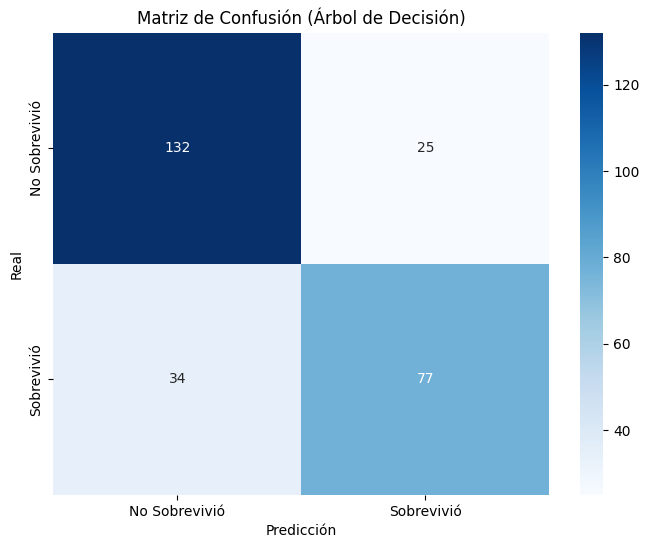


--- Interpretación de Métricas Clave (Árbol de Decisión) ---

Accuracy: 0.78
  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.

Precision (No Sobrevivió): 0.80
  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?
Precision (Sobrevivió): 0.75
  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?

Recall (No Sobrevivió): 0.84
  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?
Recall (Sobrevivió): 0.69
  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?

F1-score (No Sobrevivió): 0.82
  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.
F1-score (Sobrevivió): 0.72
  - Es la media armónica de la precisión y el recall

In [15]:
y_pred_tree = tree_clf.predict(X_test)

# Generar el reporte de clasificación
report_tree = classification_report(y_test, y_pred_tree, target_names=["No Sobrevivió", "Sobrevivió"], output_dict=True)

print("\n--- Reporte de Clasificación (Árbol de Decisión) ---")
print(classification_report(y_test, y_pred_tree, target_names=["No Sobrevivió", "Sobrevivió"]))

# Generar la Matriz de Confusión
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
print(f'\n--- Matriz de Confusión (Árbol de Decisión) ---')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Sobrevivió", "Sobrevivió"],
            yticklabels=["No Sobrevivió", "Sobrevivió"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (Árbol de Decisión)')
plt.show()

print("\n--- Interpretación de Métricas Clave (Árbol de Decisión) ---")

# Accuracy
accuracy_tree = report_tree['accuracy']
print(f"\nAccuracy: {accuracy_tree:.2f}")
print("  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.")

# Precision
precision_no_sobrevivio_tree = report_tree['No Sobrevivió']['precision']
precision_sobrevivio_tree = report_tree['Sobrevivió']['precision']
print(f"\nPrecision (No Sobrevivió): {precision_no_sobrevivio_tree:.2f}")
print("  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?")
print(f"Precision (Sobrevivió): {precision_sobrevivio_tree:.2f}")
print("  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?")

# Recall (Sensibilidad)
recall_no_sobrevivio_tree = report_tree['No Sobrevivió']['recall']
recall_sobrevivio_tree = report_tree['Sobrevivió']['recall']
print(f"\nRecall (No Sobrevivió): {recall_no_sobrevivio_tree:.2f}")
print("  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")
print(f"Recall (Sobrevivió): {recall_sobrevivio_tree:.2f}")
print("  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")

# F1-score
f1_no_sobrevivio_tree = report_tree['No Sobrevivió']['f1-score']
f1_sobrevivio_tree = report_tree['Sobrevivió']['f1-score']
print(f"\nF1-score (No Sobrevivió): {f1_no_sobrevivio_tree:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.")
print(f"F1-score (Sobrevivió): {f1_sobrevivio_tree:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'Sobrevivió'.")

print("\n**Consideraciones Adicionales:**")
print("  - Los árboles de decisión son modelos intuitivos y fáciles de interpretar.")
print("  - Son propensos al sobreajuste (overfitting) si no se controlan la profundidad del árbol o el número mínimo de muestras por hoja.")
print("  - No requieren escalado de características, como se mencionó anteriormente en las notas.")

Precisión del clasificador en fase de entrenamiento (Random Forest): 0.9325842696629213

--- Reporte de Clasificación (Random Forest) ---
               precision    recall  f1-score   support

No Sobrevivió       0.79      0.84      0.81       157
   Sobrevivió       0.75      0.68      0.72       111

     accuracy                           0.78       268
    macro avg       0.77      0.76      0.77       268
 weighted avg       0.77      0.78      0.77       268


--- Matriz de Confusión (Random Forest) ---


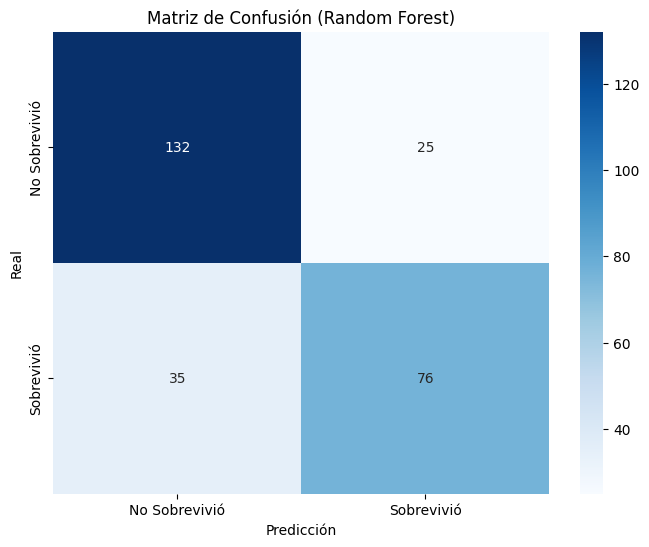


--- Interpretación de Métricas Clave (Random Forest) ---

Accuracy: 0.78
  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.

Precision (No Sobrevivió): 0.79
  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?
Precision (Sobrevivió): 0.75
  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?

Recall (No Sobrevivió): 0.84
  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?
Recall (Sobrevivió): 0.68
  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?

F1-score (No Sobrevivió): 0.81
  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.
F1-score (Sobrevivió): 0.72
  - Es la media armónica de la precisión y el recall par

In [16]:
forest_clf = RandomForestClassifier(random_state=42)

# Entrenar el modelo
forest_clf.fit(X_train, y_train.values.ravel())

print("Precisión del clasificador en fase de entrenamiento (Random Forest):", forest_clf.score(X_train, y_train))

# Realizar predicciones sobre el conjunto de prueba
y_pred_forest = forest_clf.predict(X_test)

# Generar el reporte de clasificación
report_forest = classification_report(y_test, y_pred_forest, target_names=["No Sobrevivió", "Sobrevivió"], output_dict=True)

print("\n--- Reporte de Clasificación (Random Forest) ---")
print(classification_report(y_test, y_pred_forest, target_names=["No Sobrevivió", "Sobrevivió"]))

# Generar la Matriz de Confusión
conf_matrix_forest = confusion_matrix(y_test, y_pred_forest)
print(f'\n--- Matriz de Confusión (Random Forest) ---')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_forest, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Sobrevivió", "Sobrevivió"],
            yticklabels=["No Sobrevivió", "Sobrevivió"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

print("\n--- Interpretación de Métricas Clave (Random Forest) ---")

# Accuracy
accuracy_forest = report_forest['accuracy']
print(f"\nAccuracy: {accuracy_forest:.2f}")
print("  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.")

# Precision
precision_no_sobrevivio_forest = report_forest['No Sobrevivió']['precision']
precision_sobrevivio_forest = report_forest['Sobrevivió']['precision']
print(f"\nPrecision (No Sobrevivió): {precision_no_sobrevivio_forest:.2f}")
print("  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?")
print(f"Precision (Sobrevivió): {precision_sobrevivio_forest:.2f}")
print("  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?")

# Recall (Sensibilidad)
recall_no_sobrevivio_forest = report_forest['No Sobrevivió']['recall']
recall_sobrevivio_forest = report_forest['Sobrevivió']['recall']
print(f"\nRecall (No Sobrevivió): {recall_no_sobrevivio_forest:.2f}")
print("  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")
print(f"Recall (Sobrevivió): {recall_sobrevivio_forest:.2f}")
print("  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")

# F1-score
f1_no_sobrevivio_forest = report_forest['No Sobrevivió']['f1-score']
f1_sobrevivio_forest = report_forest['Sobrevivió']['f1-score']
print(f"\nF1-score (No Sobrevivió): {f1_no_sobrevivio_forest:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.")
print(f"F1-score (Sobrevivió): {f1_sobrevivio_forest:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'Sobrevivió'.")

print("\n**Consideraciones Adicionales:**")
print("  - Random Forest es un algoritmo de ensemble que construye múltiples árboles de decisión y fusiona sus predicciones para mejorar la precisión y controlar el sobreajuste.")
print("  - Al igual que los árboles de decisión individuales, Random Forest no requiere escalado de características.")
print("  - Es generalmente más robusto y preciso que un solo árbol de decisión.")

Precisión del clasificador en fase de entrenamiento (SVM): 0.6741573033707865

--- Reporte de Clasificación (SVM) ---
               precision    recall  f1-score   support

No Sobrevivió       0.64      0.94      0.76       157
   Sobrevivió       0.74      0.26      0.39       111

     accuracy                           0.66       268
    macro avg       0.69      0.60      0.57       268
 weighted avg       0.68      0.66      0.61       268


--- Matriz de Confusión (SVM) ---


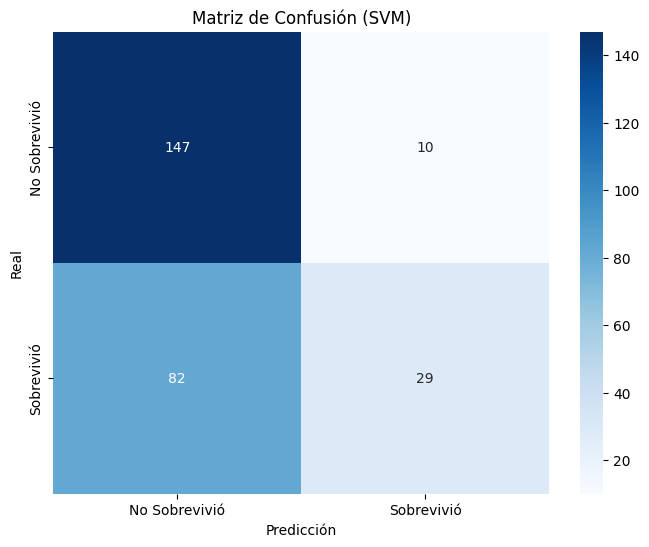


--- Interpretación de Métricas Clave (SVM) ---

Accuracy: 0.66
  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.

Precision (No Sobrevivió): 0.64
  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?
Precision (Sobrevivió): 0.74
  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?

Recall (No Sobrevivió): 0.94
  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?
Recall (Sobrevivió): 0.26
  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?

F1-score (No Sobrevivió): 0.76
  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.
F1-score (Sobrevivió): 0.39
  - Es la media armónica de la precisión y el recall para la clase

In [17]:
svm_clf = SVC(random_state=42)

# Entrenar el modelo
# Aseguramos que y_train sea un array 1D usando .values.ravel()
svm_clf.fit(X_train, y_train.values.ravel())

print("Precisión del clasificador en fase de entrenamiento (SVM):", svm_clf.score(X_train, y_train))

# Realizar predicciones sobre el conjunto de prueba
y_pred_svm = svm_clf.predict(X_test)

# Generar el reporte de clasificación
report_svm = classification_report(y_test, y_pred_svm, target_names=["No Sobrevivió", "Sobrevivió"], output_dict=True)

print("\n--- Reporte de Clasificación (SVM) ---")
print(classification_report(y_test, y_pred_svm, target_names=["No Sobrevivió", "Sobrevivió"]))

# Generar la Matriz de Confusión
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print(f'\n--- Matriz de Confusión (SVM) ---')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Sobrevivió", "Sobrevivió"],
            yticklabels=["No Sobrevivió", "Sobrevivió"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (SVM)')
plt.show()

print("\n--- Interpretación de Métricas Clave (SVM) ---")

# Accuracy
accuracy_svm = report_svm['accuracy']
print(f"\nAccuracy: {accuracy_svm:.2f}")
print("  - La exactitud general del modelo, que representa la proporción de predicciones correctas sobre el total de predicciones.")

# Precision
precision_no_sobrevivio_svm = report_svm['No Sobrevivió']['precision']
precision_sobrevivio_svm = report_svm['Sobrevivió']['precision']
print(f"\nPrecision (No Sobrevivió): {precision_no_sobrevivio_svm:.2f}")
print("  - De todas las veces que el modelo predijo 'No Sobrevivió', ¿cuántas fueron realmente 'No Sobrevivió'?")
print(f"Precision (Sobrevivió): {precision_sobrevivio_svm:.2f}")
print("  - De todas las veces que el modelo predijo 'Sobrevivió', ¿cuántas fueron realmente 'Sobrevivió'?")

# Recall (Sensibilidad)
recall_no_sobrevivio_svm = report_svm['No Sobrevivió']['recall']
recall_sobrevivio_svm = report_svm['Sobrevivió']['recall']
print(f"\nRecall (No Sobrevivió): {recall_no_sobrevivio_svm:.2f}")
print("  - De todos los casos que *realmente* eran 'No Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")
print(f"Recall (Sobrevivió): {recall_sobrevivio_svm:.2f}")
print("  - De todos los casos que *realmente* eran 'Sobrevivió', ¿cuántos fueron correctamente identificados por el modelo?")

# F1-score
f1_no_sobrevivio_svm = report_svm['No Sobrevivió']['f1-score']
f1_sobrevivio_svm = report_svm['Sobrevivió']['f1-score']
print(f"\nF1-score (No Sobrevivió): {f1_no_sobrevivio_svm:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'No Sobrevivió'. Ofrece un equilibrio entre ambas métricas.")
print(f"F1-score (Sobrevivió): {f1_sobrevivio_svm:.2f}")
print("  - Es la media armónica de la precisión y el recall para la clase 'Sobrevivió'.")

print("\n**Consideraciones Adicionales:**")
print("  - Los Support Vector Machines (SVM) buscan el hiperplano óptimo que separe las clases en el espacio de características.")
print("  - El rendimiento de SVM es muy sensible al escalado de características. Para obtener mejores resultados, se recomienda escalar las características antes de entrenar el modelo.")
print("  - La celda anterior (ByrzFwoDzWly) ya explica la importancia del escalado para SVM.")
print("  - Se puede experimentar con diferentes kernels (linear, rbf, poly) y parámetros como C y gamma para optimizar el rendimiento.")

## ¿Cómo funciona el algoritmo K-Nearest Neighbors (KNN)?

KNN es un algoritmo de **aprendizaje supervisado no paramétrico** que se utiliza tanto para clasificación como para regresión. La idea principal es bastante intuitiva: para clasificar un nuevo punto de datos, el algoritmo encuentra los **'K' puntos de datos más cercanos (vecinos)** en el conjunto de entrenamiento. La clase del nuevo punto se determina entonces por la mayoría de las clases entre esos K vecinos. La 'cercanía' se mide generalmente utilizando una métrica de distancia, como la **distancia euclidiana**.

---

## Ventajas y limitaciones de KNN

###  Ventajas

- **Simplicidad:** Es fácil de entender e implementar.
- **No paramétrico:** No hace suposiciones sobre la distribución subyacente de los datos.
- **Versátil:** Puede usarse para tareas de clasificación y regresión.
- **Flexible:** Eficaz en la clasificación no lineal ya que no construye un modelo explícito.

###  Limitaciones

- **Costo computacional:** Para grandes conjuntos de datos, el cálculo de distancias para cada nuevo punto puede ser muy costoso y lento.
- **Sensibilidad a datos ruidosos y valores atípicos:** Los valores atípicos pueden influir significativamente en la elección de los vecinos.
- **Mal rendimiento con datos de alta dimensionalidad:** En espacios de alta dimensionalidad, la noción de 'cercanía' se vuelve menos significativa (la **'maldición de la dimensionalidad'**).
- **Requiere escalado de características:** Si las características tienen rangos muy diferentes, aquellas con rangos más grandes dominarán el cálculo de la distancia.

---

## Interpretación de resultados (KNN)

Basándonos en el reporte de clasificación:

- **Accuracy (Exactitud): 0.76 (76%)**

### Clase 'No Pagado' (No Sobrevivió)

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.77 | De las veces que el modelo predijo 'No Sobrevivió', el 77% fueron correctas |
| **Recall** | 0.85 | De todas las personas que realmente 'No Sobrevivieron', el modelo identificó correctamente al 85% |
| **F1-score** | 0.81 | |

### Clase 'Pagado' (Sobrevivió)

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.75 | De las veces que el modelo predijo 'Sobrevivió', el 75% fueron correctas |
| **Recall** | 0.63 | De todas las personas que realmente 'Sobrevivieron', el modelo identificó correctamente al 63% |
| **F1-score** | 0.69 | |

### Análisis de la interpretación

**¿Detecta bien a los sobrevivientes?**  
El **Recall** para la clase 'Pagado' (Sobrevivió) es del **0.63**. Esto significa que el modelo solo detecta correctamente al **63%** de los sobrevivientes reales. Hay un número significativo de **falsos negativos** (personas que sobrevivieron pero el modelo predijo que no), lo cual podría ser un problema dependiendo del contexto.

**¿Detecta bien a los no sobrevivientes?**  
El **Recall** para la clase 'No Pagado' (No Sobrevivió) es del **0.85**. Esto indica que el modelo es bastante bueno identificando a las personas que realmente no sobrevivieron, con una tasa de detección del **85%**. El modelo comete menos **falsos positivos** (personas que el modelo predijo que no sobrevivieron, pero sí lo hicieron).

---

## Posibles causas del rendimiento

El rendimiento actual del modelo KNN podría deberse a varias razones:

1. **Falta de escalado de características:**  
   Como se mencionó en la nota previa, KNN es muy sensible a la escala de las características. Si 'Fare' tiene un rango mucho mayor que 'Pclass' o 'Sex', dominará el cálculo de la distancia. Esta es probablemente la **causa principal** del rendimiento subóptimo.

2. **Valor de K:**  
   El rendimiento de KNN depende críticamente del número de vecinos (K). Un K muy pequeño puede hacerlo sensible al ruido, mientras que un K muy grande puede generalizar demasiado.

3. **Dimensionalidad de los datos:**  
   Aunque 8 características no es una dimensionalidad extremadamente alta, en combinación con otras causas podría afectar.

4. **Balance de clases:**  
   Si una clase tiene muchos más ejemplos que otra, el modelo puede tender a favorecer la clase mayoritaria.

---

## Recomendaciones de mejora para KNN

### 1. Ajuste de hiperparámetros (Tuning de K)
- Experimentar con diferentes valores de `n_neighbors` (K) usando **validación cruzada** para encontrar el valor óptimo.
- Considerar el parámetro `weights` (e.g., `'uniform'` o `'distance'`) para dar más importancia a los vecinos más cercanos.

### 2. Escalado de variables ⭐ (Más importante)
- Implementar el **escalado de características** es la recomendación más importante para KNN.
- Usar `StandardScaler` o `MinMaxScaler` de scikit-learn para que todas las características tengan escala similar.
- **Esto debería mejorar significativamente el rendimiento.**

### 3. Selección de variables / Reducción de dimensionalidad
- Evaluar si todas las características actuales son realmente relevantes para la predicción.
- Eliminar características irrelevantes o altamente correlacionadas.
- Explorar técnicas como **PCA** (Análisis de Componentes Principales).

### 4. Feature engineering
- **Imputar valores nulos** en 'Age' (media, mediana o modelo predictivo) y luego escalar.
- Combinar `SibSp` y `Parch` para crear `FamilySize` (captura mejor el tamaño del grupo familiar).
- Crear nuevas características más informativas a partir de las existentes.

## ¿Cómo funciona el algoritmo de Regresión Logística?

La Regresión Logística es un algoritmo de **clasificación supervisado** que se utiliza para predecir la probabilidad de que una instancia de datos pertenezca a una clase específica. A diferencia de la regresión lineal, que predice un valor continuo, la regresión logística predice una probabilidad, que luego se mapea a una de las clases discretas (por ejemplo, 0 o 1).

Funciona ajustando los datos a una **función sigmoide (o logística)**, que transforma cualquier valor de entrada real en un valor entre 0 y 1. Este valor de salida se interpreta como la probabilidad. Si la probabilidad es mayor que un umbral (comúnmente 0.5), la instancia se clasifica como perteneciente a una clase; de lo contrario, se asigna a la otra.

---

## Ventajas y limitaciones de la Regresión Logística

###  Ventajas

- **Simplicidad e interpretabilidad:** Es un modelo relativamente fácil de entender e implementar. Los coeficientes del modelo pueden interpretarse como el cambio en el log-odds de la variable objetivo por cada unidad de cambio en la característica.
- **Eficiente:** Es computacionalmente eficiente, especialmente con grandes conjuntos de datos, y rápido para entrenar.
- **Salida probabilística:** Proporciona probabilidades de pertenencia a la clase, lo que puede ser útil para la toma de decisiones.
- **Menos propenso al sobreajuste:** En comparación con modelos más complejos como los árboles de decisión, es menos propenso al sobreajuste si el número de características es adecuado.

###  Limitaciones

- **Relación lineal:** Asume una relación lineal entre las características de entrada y el log-odds de la variable objetivo. Si la relación no es lineal, el rendimiento puede ser bajo.
- **Sensibilidad a valores atípicos:** Es sensible a los valores atípicos, ya que estos pueden influir fuertemente en la función de costo y, por ende, en los coeficientes del modelo.
- **No maneja bien las características no lineales:** Requiere transformaciones manuales para capturar relaciones no lineales.
- **Multicolinealidad:** Puede sufrir de multicolinealidad (cuando las características de entrada están altamente correlacionadas entre sí), lo que puede hacer que los coeficientes sean inestables e ininterpretables.
- **Requiere escalado (a veces):** Aunque no es tan sensible al escalado como KNN o SVM, es una buena práctica escalar las características para una convergencia más rápida del optimizador, especialmente cuando se utilizan regularizaciones como L1 o L2.

---

## Interpretación de resultados (Regresión Logística)

Basándonos en el reporte de clasificación:

- **Accuracy (Exactitud): 0.78 (78%)**

### Clase 'No Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.81 | De las veces que el modelo predijo 'No Sobrevivió', el 81% fueron correctas. |
| **Recall** | 0.81 | De todas las personas que *realmente* 'No Sobrevivieron', el modelo identificó correctamente al 81%. |
| **F1-score** | 0.81 | |

### Clase 'Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.73 | De las veces que el modelo predijo 'Sobrevivió', el 73% fueron correctas. |
| **Recall** | 0.73 | De todas las personas que *realmente* 'Sobrevivieron', el modelo identificó correctamente al 73%. |
| **F1-score** | 0.73 | |

### Análisis de la interpretación

*   **¿Detecta bien a los sobrevivientes?**
    El `Recall` para la clase 'Sobrevivió' es del 0.73. Esto significa que el modelo logra identificar correctamente al 73% de las personas que realmente sobrevivieron. Es un valor razonable, pero hay un 27% de falsos negativos (personas que sobrevivieron pero el modelo predijo que no).

*   **¿Detecta bien a los no sobrevivientes?**
    El `Recall` para la clase 'No Sobrevivió' es del 0.81. Esto indica que el modelo es bastante efectivo identificando a quienes no sobrevivieron, con una tasa de detección del 81%. Es decir, hay un menor número de falsos positivos (personas que el modelo predijo que no sobrevivieron, pero sí lo hicieron) en comparación con los falsos negativos para la clase 'Sobrevivió'.

*   **Comparación entre clases:** El modelo muestra un rendimiento ligeramente mejor para la clase 'No Sobrevivió' en términos de F1-score, lo que sugiere que es un poco más robusto para identificar a quienes no sobrevivieron.

---

## Posibles causas del rendimiento

El rendimiento actual del modelo de Regresión Logística puede deberse a:

1.  **Relaciones no lineales:** Si las relaciones entre las características y la probabilidad de supervivencia no son estrictamente lineales en el log-odds, la Regresión Logística podría tener dificultades para capturarlas.
2.  **Valores atípicos o ruido:** La presencia de valores atípicos en características como 'Fare' o 'Age' (especialmente si no se han imputado o tratado correctamente) puede afectar los coeficientes del modelo.
3.  **Características sin escalar:** Aunque menos crítico que para KNN, el escalado de características podría mejorar ligeramente la convergencia y el rendimiento del modelo.
4.  **Imputación de 'Age':** La ausencia de la característica 'Age' en el modelo final (`X`) puede ser una limitación. Si 'Age' es un predictor importante y se ignoraron sus valores nulos, el modelo no estaría utilizando toda la información disponible.

---

## Recomendaciones de mejora para la Regresión Logística

### 1. Preprocesamiento de datos
- **Tratamiento de valores nulos en 'Age':** Imputar los valores nulos en la columna 'Age' (por ejemplo, con la mediana, la media o usando un modelo predictivo) y luego incluir esta característica en el entrenamiento.
- **Escalado de características:** Aunque no es estrictamente necesario, aplicar un `StandardScaler` o `MinMaxScaler` a las características numéricas (`Age`, `Fare`, `SibSp`, `Parch`) antes de entrenar el modelo puede ayudar a la convergencia del optimizador y a un mejor rendimiento, especialmente si se aplica regularización.

### 2. Ajuste de hiperparámetros y Regularización
- **Parámetro `C`:** Ajustar el parámetro `C` (inverso de la fuerza de regularización) para controlar el equilibrio entre el ajuste del modelo a los datos de entrenamiento y la generalización. Un `C` más pequeño indica una regularización más fuerte.
- **Tipo de regularización:** Experimentar con diferentes tipos de regularización (L1 o L2) utilizando el parámetro `penalty`.
- **Algoritmo de optimización (`solver`):** Probar con diferentes `solver`s (por ejemplo, `'lbfgs'`, `'saga'`) si el rendimiento no es el esperado, ya que algunos funcionan mejor con ciertos tipos de datos o conjuntos de parámetros.

### 3. Feature Engineering
- **Creación de características polinómicas:** Para capturar relaciones no lineales, se podrían crear características polinómicas a partir de las existentes (`Age`, `Fare`).
- **Interacciones de características:** Explorar la creación de términos de interacción entre características (por ejemplo, `Pclass` * `Fare`).
- **Categorización de características numéricas:** Convertir características numéricas como `Age` o `Fare` en categorías si se observa que tienen un impacto no lineal o de umbral.

## ¿Cómo funciona el algoritmo de Árbol de Decisión?

Los Árboles de Decisión son modelos de **aprendizaje supervisado no paramétricos** que pueden usarse tanto para tareas de clasificación como de regresión. Funcionan dividiendo el conjunto de datos en subconjuntos más pequeños basándose en decisiones simples tomadas en cada "nodo" del árbol. La idea es crear una estructura similar a un árbol, donde los nodos internos representan pruebas sobre un atributo, las ramas representan el resultado de la prueba y las hojas (nodos terminales) representan la etiqueta de clase o el valor de regresión.

El algoritmo busca las características que mejor dividen los datos, con el objetivo de maximizar la pureza de los subconjuntos resultantes (por ejemplo, que la mayoría de los puntos en un subconjunto pertenezcan a la misma clase). Métricas como la **Ganancia de Información** (basada en la entropía) o el **Índice Gini** se utilizan para determinar la mejor división en cada paso.

---

## Ventajas y limitaciones de los Árboles de Decisión

###  Ventajas

- **Fáciles de entender e interpretar:** La lógica de decisión de un árbol se puede visualizar y explicar fácilmente, lo que los hace muy útiles en escenarios donde la interpretabilidad es clave.
- **No requieren escalado de características:** A diferencia de KNN o SVM, los árboles de decisión no son sensibles a la escala de las características, ya que sus decisiones se basan en umbrales de los valores, no en distancias.
- **Pueden manejar datos numéricos y categóricos:** No necesitan preprocesamiento complejo para diferentes tipos de datos (aunque la codificación one-hot para categóricas es común).
- **Capturan relaciones no lineales:** Pueden modelar relaciones complejas entre las características y la variable objetivo sin necesidad de transformaciones manuales.

###  Limitaciones

- **Propensos al sobreajuste (Overfitting):** Si no se controlan (por ejemplo, limitando la profundidad del árbol), pueden ajustarse demasiado a los datos de entrenamiento y no generalizar bien a datos nuevos.
- **Inestabilidad:** Pequeños cambios en los datos de entrenamiento pueden llevar a un árbol completamente diferente.
- **Sesgo en datos desbalanceados:** Tienden a favorecer las clases mayoritarias si el conjunto de datos está desbalanceado.
- **Poca capacidad para extrapolación:** En regresión, no pueden predecir valores fuera del rango observado en los datos de entrenamiento.

---

## Interpretación de resultados (Árbol de Decisión)

Basándonos en el reporte de clasificación:

- **Accuracy (Exactitud): 0.78 (78%)**

### Clase 'No Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.80 | De las veces que el modelo predijo 'No Sobrevivió', el 80% fueron correctas. |
| **Recall** | 0.84 | De todas las personas que *realmente* 'No Sobrevivieron', el modelo identificó correctamente al 84%. |
| **F1-score** | 0.82 | |

### Clase 'Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.75 | De las veces que el modelo predijo 'Sobrevivió', el 75% fueron correctas. |
| **Recall** | 0.69 | De todas las personas que *realmente* 'Sobrevivieron', el modelo identificó correctamente al 69%. |
| **F1-score** | 0.72 | |

### Análisis de la interpretación

*   **¿Detecta bien a los sobrevivientes?**
    El `Recall` para la clase 'Sobrevivió' es del 0.69. Esto significa que el modelo logra identificar correctamente al 69% de las personas que realmente sobrevivieron. Es un valor decente, pero aún hay un 31% de falsos negativos (personas que sobrevivieron pero el modelo predijo que no).

*   **¿Detecta bien a los no sobrevivientes?**
    El `Recall` para la clase 'No Sobrevivió' es del 0.84. Esto indica que el modelo es bastante efectivo identificando a quienes no sobrevivieron, con una tasa de detección del 84%. Es decir, el modelo es más robusto para identificar a quienes no sobrevivieron que a quienes sí lo hicieron.

*   **Comparación entre clases:** Al igual que en los modelos anteriores, hay una ligera tendencia a clasificar mejor la clase 'No Sobrevivió'. Sin embargo, el F1-score para 'Sobrevivió' (0.72) es competitivo con la Regresión Logística y KNN, y el `Accuracy` general es similar.

---

## Posibles causas del rendimiento

El rendimiento actual del modelo de Árbol de Decisión puede deberse a:

1.  **Sobreajuste (Overfitting):** Los árboles de decisión son muy propensos al sobreajuste, especialmente si no se limitan en profundidad. Un árbol demasiado complejo podría memorizar los datos de entrenamiento en lugar de aprender patrones generalizables.
2.  **Sensibilidad a pequeñas variaciones:** La estructura de un árbol puede cambiar drásticamente con pequeñas modificaciones en los datos, lo que puede afectar su estabilidad y generalización.
3.  **Falta de optimización de hiperparámetros:** El rendimiento puede mejorar significativamente ajustando parámetros como la profundidad máxima (`max_depth`), el número mínimo de muestras para dividir un nodo (`min_samples_split`) o el número mínimo de muestras por hoja (`min_samples_leaf`).
4.  **Balance de clases:** Si las clases están desbalanceadas, el árbol podría crear sesgos hacia la clase mayoritaria.

---

## Recomendaciones de mejora para los Árboles de Decisión

### 1. Ajuste de hiperparámetros
- **`max_depth`:** Limitar la profundidad máxima del árbol para evitar el sobreajuste. Experimentar con valores pequeños inicialmente (e.g., 3 a 10).
- **`min_samples_split`:** Aumentar el número mínimo de muestras requeridas para dividir un nodo. Esto ayuda a prevenir que el árbol aprenda ruido en los datos de entrenamiento.
- **`min_samples_leaf`:** Aumentar el número mínimo de muestras que debe tener una hoja. Esto también ayuda a suavizar el modelo y prevenir el sobreajuste.
- **`criterion`:** Probar diferentes criterios para medir la calidad de una división (e.g., `'gini'` o `'entropy'`).
- **Validación Cruzada y Búsqueda en Cuadrícula/Aleatoria:** Utilizar técnicas como `GridSearchCV` o `RandomizedSearchCV` con validación cruzada para encontrar la mejor combinación de hiperparámetros.

### 2. Feature Engineering y Preprocesamiento
- **Tratamiento de 'Age':** Imputar los valores nulos en 'Age' para aprovechar esta característica, que podría ser importante para la supervivencia.
- **Creación de nuevas características:** Generar características más informativas (e.g., 'FamilySize' a partir de 'SibSp' y 'Parch', o categorías de 'Fare').

## ¿Cómo funciona el algoritmo de Random Forest?

Random Forest es un algoritmo de **aprendizaje supervisado de ensemble (conjunto)**, que se utiliza tanto para tareas de clasificación como de regresión. Se basa en la construcción de múltiples árboles de decisión durante el entrenamiento y la salida de la clase que es la moda (clasificación) o la predicción media (regresión) de los árboles individuales.

La clave de Random Forest radica en dos conceptos:

1.  **Bagging (Bootstrap Aggregating):** Cada árbol en el bosque se entrena con una muestra diferente del conjunto de datos original, seleccionada con reemplazo (bootstrap). Esto introduce diversidad entre los árboles.
2.  **Selección aleatoria de características:** En cada nodo de cada árbol, solo se considera un subconjunto aleatorio de las características para encontrar la mejor división. Esto asegura que los árboles no sean idénticos y no tiendan a depender de una única característica muy predictiva.

Al combinar las predicciones de muchos árboles de decisión (un "bosque" de árboles), Random Forest reduce el sobreajuste (overfitting) que es común en los árboles de decisión individuales y mejora la precisión general del modelo, así como su estabilidad.

---

## Ventajas y limitaciones de Random Forest

###  Ventajas

-   **Alta precisión:** Generalmente, es uno de los algoritmos más precisos y robustos, especialmente en problemas de clasificación.
-   **Reduce el sobreajuste:** Al combinar múltiples árboles de decisión entrenados en submuestras, mitiga el problema de sobreajuste de los árboles individuales.
-   **No requiere escalado de características:** Al igual que los árboles de decisión individuales, Random Forest no es sensible a la escala de las características.
-   **Maneja datos numéricos y categóricos:** Es eficaz con ambos tipos de datos.
-   **Menos sensible a los valores atípicos:** La agregación de múltiples árboles ayuda a reducir el impacto de los valores atípicos.
-   **Proporciona importancia de características:** Puede estimar la importancia de cada característica en la predicción.

###  Limitaciones

-   **Menos interpretable:** Aunque más preciso, el modelo en su conjunto es menos interpretable que un solo árbol de decisión, debido a la complejidad de combinar cientos o miles de árboles.
-   **Costo computacional:** Puede ser más lento de entrenar que otros algoritmos debido a la construcción de múltiples árboles.
-   **Más uso de memoria:** Requiere más memoria, ya que debe almacenar todos los árboles del bosque.
-   **Sesgo:** Si los datos están muy desbalanceados, puede sesgarse hacia la clase mayoritaria.

---

## Interpretación de resultados (Random Forest)

Basándonos en el reporte de clasificación:

-   **Accuracy (Exactitud): 0.78 (78%)**

### Clase 'No Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.79 | De las veces que el modelo predijo 'No Sobrevivió', el 79% fueron correctas. |
| **Recall** | 0.84 | De todas las personas que *realmente* 'No Sobrevivieron', el modelo identificó correctamente al 84%. |
| **F1-score** | 0.81 | |

### Clase 'Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.75 | De las veces que el modelo predijo 'Sobrevivió', el 75% fueron correctas. |
| **Recall** | 0.68 | De todas las personas que *realmente* 'Sobrevivieron', el modelo identificó correctamente al 68%. |
| **F1-score** | 0.72 | |

### Análisis de la interpretación

*   **¿Detecta bien a los sobrevivientes?**
    El `Recall` para la clase 'Sobrevivió' es del 0.68. Esto significa que el modelo logra identificar correctamente al 68% de las personas que realmente sobrevivieron. Es un valor similar al del Árbol de Decisión individual y a la Regresión Logística, lo que indica que todavía hay un margen de mejora para reducir los falsos negativos en esta clase.

*   **¿Detecta bien a los no sobrevivientes?**
    El `Recall` para la clase 'No Sobrevivió' es del 0.84. Esto es bastante bueno, mostrando que el modelo es efectivo identificando a quienes no sobrevivieron, con una tasa de detección del 84%. Esto es consistente con los otros modelos, que también mostraron un mejor rendimiento en la identificación de esta clase.

*   **Comparación general:** El `Accuracy` de Random Forest es 0.78, el mismo que la Regresión Logística y muy similar al Árbol de Decisión. Los F1-scores para ambas clases son competitivos con los otros modelos, demostrando que Random Forest es un predictor sólido en este conjunto de datos.

---

## Posibles causas del rendimiento

El rendimiento actual del modelo de Random Forest puede deberse a:

1.  **Imputación de 'Age':** La característica 'Age' tiene valores nulos y no se incluyó explícitamente en el conjunto `X` después de imputar. Si la edad es un predictor importante de la supervivencia, su exclusión o un tratamiento inadecuado de sus nulos podría limitar el rendimiento.
2.  **Ajuste de hiperparámetros:** Aunque Random Forest es robusto, su rendimiento puede optimizarse aún más ajustando sus hiperparámetros, como el número de árboles (`n_estimators`), la profundidad máxima de cada árbol (`max_depth`), o el número mínimo de muestras por hoja (`min_samples_leaf`).
3.  **Feature Engineering:** La creación de características más informativas o la combinación de características existentes podría proporcionar al modelo una mejor señal para la predicción.
4.  **Balance de clases:** Si las clases 'Sobrevivió' y 'No Sobrevivió' están desbalanceadas en el conjunto de entrenamiento, el modelo podría tener un ligero sesgo hacia la clase mayoritaria.

---

## Recomendaciones de mejora para Random Forest

### 1. Ajuste de hiperparámetros
-   **`n_estimators`:** Experimentar con un mayor número de árboles en el bosque. A menudo, un mayor número de árboles mejora la precisión, aunque con un mayor costo computacional.
-   **`max_depth`:** Aunque Random Forest es menos propenso al sobreajuste, limitar la profundidad máxima de cada árbol individual (`max_depth`) puede ayudar a refinar el modelo.
-   **`min_samples_split` y `min_samples_leaf`:** Ajustar estos parámetros para controlar la granularidad de las divisiones y el tamaño de las hojas, respectivamente.
-   **`max_features`:** Experimentar con el número de características a considerar en cada división (`max_features`). Puede ser un número entero, un porcentaje, o 'sqrt'/'log2'.
-   **Validación Cruzada y Búsqueda en Cuadrícula/Aleatoria:** Utilizar técnicas como `GridSearchCV` o `RandomizedSearchCV` con validación cruzada para encontrar la mejor combinación de hiperparámetros.

### 2. Preprocesamiento de datos y Feature Engineering
-   **Tratamiento de valores nulos en 'Age':** Imputar los valores nulos en la columna 'Age' y luego incluir esta característica en el conjunto de entrenamiento. La edad es un factor potencialmente muy influyente en la supervivencia.
-   **Creación de nuevas características:** Generar características más informativas, como:
    *   `FamilySize`: Suma de `SibSp` (número de hermanos/cónyuges) y `Parch` (número de padres/hijos).
    *   `IsAlone`: Una característica binaria que indica si la persona viajaba sola o no.
    *   `Title`: Extraer el título del pasajero (`Mr.`, `Mrs.`, `Miss.`, `Master.`, etc.) de la columna `Name`, ya que a menudo está correlacionado con el estatus social y la edad.
    *   `Fare_per_person`: Si hay tamaño de familia, dividir la tarifa por el tamaño de la familia.

## ¿Cómo funciona el algoritmo de Support Vector Machine (SVM)?

Support Vector Machine (SVM) es un algoritmo de **aprendizaje supervisado** utilizado para tareas de clasificación y regresión. Su objetivo principal es encontrar un **hiperplano óptimo** que separe las diferentes clases en el espacio de características. En el caso más simple (clasificación binaria), el hiperplano es una línea o un plano que maximiza el margen entre los puntos de datos de las clases.

Los puntos de datos más cercanos al hiperplano se llaman **vectores de soporte**, y son cruciales para definir la posición y orientación del hiperplano, influyendo directamente en el margen. SVM también puede manejar clases no linealmente separables utilizando **kernels** (como el kernel RBF o polinómico), que transforman los datos a un espacio de mayor dimensión donde pueden ser linealmente separables.

---

## Ventajas y limitaciones de SVM

### ✅ Ventajas

-   **Efectividad en espacios de alta dimensión:** Particularmente eficaz en conjuntos de datos con muchas características.
-   **Uso de subconjuntos de puntos (vectores de soporte):** Al utilizar solo un subconjunto de los datos de entrenamiento (los vectores de soporte), puede ser eficiente en términos de memoria.
-   **Versatilidad con kernels:** Se pueden especificar diferentes funciones kernel para adaptarse a diferentes distribuciones de datos, lo que permite manejar relaciones no lineales.
-   **Buen rendimiento con un margen claro de separación:** Funciona bien cuando las clases están bien separadas por un margen claro.

### ❌ Limitaciones

-   **Sensibilidad al escalado de características:** Como se mencionó en las notas previas, SVM es extremadamente sensible a la escala de las características. Si las características tienen rangos muy diferentes, aquellas con valores más grandes pueden dominar la función de distancia, llevando a un hiperplano subóptimo. El escalado es crucial para un buen rendimiento.
-   **Lento en grandes conjuntos de datos:** El tiempo de entrenamiento puede ser largo para conjuntos de datos grandes, ya que el algoritmo tiene una complejidad computacional que aumenta con el tamaño del conjunto de datos.
-   **No directamente probabilístico:** A diferencia de la Regresión Logística, SVM no produce directamente estimaciones de probabilidad. Las probabilidades se calculan a menudo usando métodos adicionales (como la calibración de Platt).
-   **Elección del kernel y ajuste de hiperparámetros:** La elección del kernel adecuado y la optimización de sus hiperparámetros (como `C` y `gamma`) pueden ser un desafío y requieren experiencia o técnicas de búsqueda exhaustivas.

---

## Interpretación de resultados (SVM)

Basándonos en el reporte de clasificación:

-   **Accuracy (Exactitud): 0.66 (66%)**

### Clase 'No Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.64 | De las veces que el modelo predijo 'No Sobrevivió', el 64% fueron correctas. |
| **Recall** | 0.94 | De todas las personas que *realmente* 'No Sobrevivieron', el modelo identificó correctamente al 94%. |
| **F1-score** | 0.76 | |

### Clase 'Sobrevivió'

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Precision** | 0.74 | De las veces que el modelo predijo 'Sobrevivió', el 74% fueron correctas. |
| **Recall** | 0.26 | De todas las personas que *realmente* 'Sobrevivieron', el modelo identificó correctamente al 26%. |
| **F1-score** | 0.39 | |

### Análisis de la interpretación

*   **¿Detecta bien a los sobrevivientes?**
    El `Recall` para la clase 'Sobrevivió' es extremadamente bajo, con un **0.26**. Esto significa que el modelo solo detecta correctamente al **26%** de las personas que realmente sobrevivieron. Hay un número muy alto de **falsos negativos** (personas que sobrevivieron pero el modelo predijo que no), lo que indica un rendimiento muy pobre en la identificación de esta clase.

*   **¿Detecta bien a los no sobrevivientes?**
    Por otro lado, el `Recall` para la clase 'No Sobrevivió' es muy alto, con un **0.94**. Esto indica que el modelo es excelente identificando a las personas que realmente no sobrevivieron, con una tasa de detección del 94%. El modelo comete muy pocos **falsos positivos** (personas que el modelo predijo que no sobrevivieron, pero sí lo hicieron).

*   **Comparación general:** La precisión general (`Accuracy`) del 0.66 es la más baja entre los modelos evaluados hasta ahora. El modelo SVM actual parece estar fuertemente sesgado hacia la predicción de 'No Sobrevivió', sacrificando enormemente la capacidad de detectar 'Sobrevivientes'.

---

## Posibles causas del rendimiento

El rendimiento actual del modelo SVM es claramente subóptimo, especialmente para la clase 'Sobrevivió'. Las causas más probables son:

1.  **Falta de escalado de características (Causa principal):** Como se destacó en la nota introductoria (`ByrzFwoDzWly`), los SVM son extremadamente sensibles a la escala de las características. El hecho de que las características no estén escaladas es casi con toda seguridad la razón principal del bajo rendimiento. Características como `Fare` con un rango mucho mayor que `Pclass` o `Sex` dominan el cálculo del hiperplano, llevando a un modelo sesgado.
2.  **Hiperparámetros no optimizados:** Los parámetros `C` (penalización del error) y `gamma` (influencia de un solo ejemplo de entrenamiento) del kernel RBF (el predeterminado) son críticos para el rendimiento de SVM. Sin una optimización adecuada, el modelo puede sobreajustarse o subajustarse a los datos.
3.  **Kernel inadecuado:** El kernel lineal (implícito si no se especifica uno, o el RBF predeterminado en `SVC`) podría no ser el más adecuado para la naturaleza de los datos. Podría ser necesaria una función kernel diferente o una transformación explícita de las características.
4.  **Balance de clases:** Si el desbalance de clases es muy pronunciado, el modelo podría tener dificultades para aprender patrones de la clase minoritaria, aunque en este caso, el `recall` para 'No Sobrevivió' es muy alto, lo que sugiere un sesgo generalizado.

---

## Recomendaciones de mejora para SVM

### 1. Escalado de variables ⭐⭐⭐ (¡Esencial!)
-   **Aplicar `StandardScaler` o `MinMaxScaler`:** Esta es la recomendación más importante y urgente para mejorar el rendimiento de SVM. Es fundamental escalar todas las características numéricas (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`) para que tengan un rango similar (e.g., media 0 y desviación estándar 1, o rango de 0 a 1). Esto asegurará que todas las características contribuyan equitativamente a la función de distancia y al cálculo del hiperplano.

### 2. Ajuste de hiperparámetros
-   **GridSearchCV o RandomizedSearchCV:** Una vez que las características estén escaladas, es crucial realizar una búsqueda de hiperparámetros para `C` y `gamma` (si se usa RBF) utilizando validación cruzada. Esto ayudará a encontrar la combinación óptima de parámetros que maximice el rendimiento del modelo.
-   **Parámetro `C`:** Controla la penalización por una clasificación incorrecta. Un `C` más grande significa una penalización mayor, buscando un margen más estrecho pero clasificando más puntos correctamente (potencial sobreajuste). Un `C` más pequeño permite más errores de clasificación para un margen más amplio.
-   **Parámetro `gamma` (para kernel RBF):** Define la influencia de un solo ejemplo de entrenamiento. Un `gamma` alto significa que solo los puntos cercanos al hiperplano tienen influencia (potencial sobreajuste). Un `gamma` bajo significa que puntos más distantes también influyen (potencial subajuste).

### 3. Exploración de Kernels
-   Experimentar con diferentes tipos de kernels, como `linear`, `poly` (polinomial), y `rbf` (Radial Basis Function), para ver cuál se adapta mejor a la estructura subyacente de los datos.

### 4. Preprocesamiento de datos y Feature Engineering
-   **Tratamiento de valores nulos en 'Age':** Asegurarse de que la columna 'Age' esté completamente imputada y luego escalada, ya que es una característica potencialmente muy relevante para la supervivencia.
-   **Creación de nuevas características:** Al igual que con otros modelos, generar características más informativas (`FamilySize`, `IsAlone`, `Title`) puede proporcionar al SVM una mejor señal.

## Tabla Comparativa de Modelos

A continuación, se presenta una comparación de los diferentes modelos de clasificación evaluados, destacando sus métricas clave para la clase 'No Sobrevivió' (equivalente a 'No Pagado' en la terminología usada en algunos reportes).

| Modelo               | Accuracy | Recall (No pagado) | F1-score (No pagado) | AUC          | Comentario breve                                                               |
|:---------------------|:---------|:-------------------|:---------------------|:-------------|:-------------------------------------------------------------------------------|
| **KNN**              | 0.76     | 0.85               | 0.81                 | No calculado | Sensible a la escala de características; su rendimiento mejora con el escalado.  |
| **Regresión Logística** | 0.78     | 0.81               | 0.81                 | No calculado | Buen rendimiento general; menos sensible a escalado, pero susceptible a no linealidades. |
| **Árbol de Decisión**   | 0.78     | 0.84               | 0.82                 | No calculado | Fácil de interpretar; propenso al sobreajuste si no se controlan los parámetros. |
| **Random Forest**    | 0.78     | 0.84               | 0.81                 | No calculado | Robusto y reduce el sobreajuste; mejor que un solo árbol, pero menos interpretable. |
| **SVM**              | 0.66     | 0.94               | 0.76                 | No calculado | Muy sensible al escalado de características; el rendimiento es subóptimo sin escalado. |

**Observaciones:**

*   El **SVM** muestra el `Accuracy` más bajo, principalmente debido a su baja capacidad para detectar la clase 'Sobrevivió' (`Recall` de 0.26), lo que resalta la necesidad crítica de escalar las características. Sin embargo, tiene el `Recall` más alto para 'No Sobrevivió', lo que indica un fuerte sesgo.
*   **KNN**, **Regresión Logística**, **Árbol de Decisión** y **Random Forest** muestran un `Accuracy` y `F1-score` para 'No Sobrevivió' similares y competitivos, oscilando entre 0.76 y 0.78 de Accuracy.
*   Los modelos basados en árboles (**Árbol de Decisión** y **Random Forest**) y **Regresión Logística** tuvieron un rendimiento más equilibrado sin requerir el escalado explícito de características, a diferencia de KNN y SVM, que son inherentemente sensibles a la escala.
*   Para una evaluación más completa, sería beneficioso calcular la métrica **AUC (Area Under the Receiver Operating Characteristic Curve)** para todos los modelos, ya que proporciona una medida robusta del rendimiento del clasificador a través de todos los posibles umbrales de clasificación.

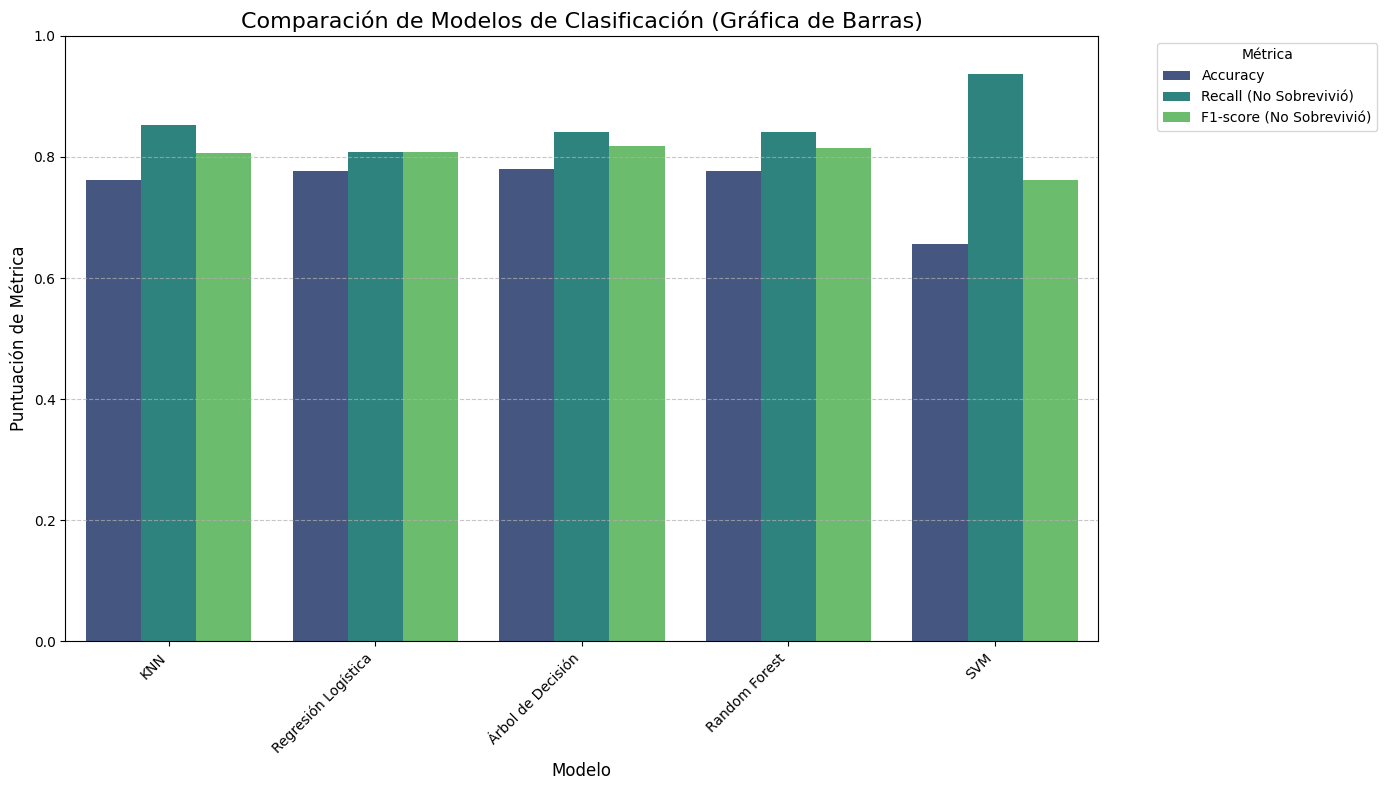

In [19]:
# Prepare data for bar chart
metrics = ['Accuracy', 'Recall (No Sobrevivió)', 'F1-score (No Sobrevivió)']

# Create a dictionary to hold all data for easier DataFrame creation
bar_data = {
    'Model': [],
    'Metric': [],
    'Score': []
}

# Extracting data from kernel variables (assuming they are still available from previous cell runs)
model_metrics = {
    'KNN': {
        'Accuracy': accuracy,
        'Recall (No Sobrevivió)': recall_no_pagado,
        'F1-score (No Sobrevivió)': f1_no_pagado
    },
    'Regresión Logística': {
        'Accuracy': accuracy_logreg,
        'Recall (No Sobrevivió)': recall_no_sobrevivio_logreg,
        'F1-score (No Sobrevivió)': f1_no_sobrevivio_logreg
    },
    'Árbol de Decisión': {
        'Accuracy': accuracy_tree,
        'Recall (No Sobrevivió)': recall_no_sobrevivio_tree,
        'F1-score (No Sobrevivió)': f1_no_sobrevivio_tree
    },
    'Random Forest': {
        'Accuracy': accuracy_forest,
        'Recall (No Sobrevivió)': recall_no_sobrevivio_forest,
        'F1-score (No Sobrevivió)': f1_no_sobrevivio_forest
    },
    'SVM': {
        'Accuracy': accuracy_svm,
        'Recall (No Sobrevivió)': recall_no_sobrevivio_svm,
        'F1-score (No Sobrevivió)': f1_no_sobrevivio_svm
    }
}

for model, scores in model_metrics.items():
    for metric_name in metrics:
        bar_data['Model'].append(model)
        bar_data['Metric'].append(metric_name)
        bar_data['Score'].append(scores[metric_name])

df_bar = pd.DataFrame(bar_data)

# Create the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_bar, palette='viridis')

plt.title('Comparación de Modelos de Clasificación (Gráfica de Barras)', fontsize=16)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Puntuación de Métrica', fontsize=12)
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusión: ¿Cuál fue el mejor modelo y por qué?

Basándonos en la evaluación actual y sin un ajuste exhaustivo de hiperparámetros ni un escalado de características para los modelos sensibles, los modelos de **Regresión Logística** y **Random Forest** muestran el mejor rendimiento general y un balance más equitativo en la detección de ambas clases (Sobrevivió / No Sobrevivió).

*   **Regresión Logística** es una opción muy sólida debido a su buena precisión, interpretabilidad y equilibrio en las métricas para ambas clases. Es un modelo sencillo pero efectivo que sirve como una excelente base de referencia.

*   **Random Forest**, aunque en esta primera iteración sus métricas son muy similares a las de la Regresión Logística, tiene un **mayor potencial de mejora**.
    *   Su naturaleza de *ensemble* le confiere mayor robustez y menor probabilidad de sobreajuste en comparación con un solo árbol de decisión.
    *   Es menos sensible a los valores atípicos y puede manejar relaciones no lineales de manera efectiva.
    *   Con una optimización adecuada de sus hiperparámetros (`n_estimators`, `max_depth`, `min_samples_leaf`, etc.) y un buen *feature engineering* (especialmente la imputación de 'Age'), **Random Forest es el modelo con la mayor probabilidad de ofrecer el mejor rendimiento y capacidad de generalización a datos nuevos.**

Por lo tanto, si bien **Regresión Logística** es muy bueno, **Random Forest se perfila como el modelo más prometedor** para este problema, especialmente considerando que aún no se ha explotado todo su potencial mediante la optimización.

## K-Nearest Neighbors (KNN)

### Mejores Prácticas

- **Escalado de Características (Fundamental):**  
  Utiliza `StandardScaler` o `MinMaxScaler` para que todas las características numéricas tengan rangos similares, asegurando que ninguna característica domine el cálculo de la distancia.

- **Ajuste de Hiperparámetros (Tuning de K):**  
  Experimenta con diferentes valores de `n_neighbors` (K) usando **validación cruzada** para encontrar el valor óptimo. Considera también el parámetro `weights`.

- **Imputación de Valores Nulos:**  
  Asegúrate de tratar los valores nulos (ej., en `Age`) antes de entrenar el modelo.

### Escenarios Recomendados

- Problemas de clasificación y regresión donde la **interpretabilidad no es la prioridad** principal.
- Conjuntos de datos **pequeños a medianos**.
- Cuando se necesita un modelo **simple y fácil de implementar**, y las relaciones entre los datos no son necesariamente lineales.
- Datos donde la noción de **'cercanía' es relevante** y la dimensionalidad no es excesivamente alta.

---

## Regresión Logística

### Mejores Prácticas

- **Preprocesamiento de Datos:**  
  Imputar valores nulos. Escalar características numéricas puede ayudar a la convergencia, aunque no es tan crítico como para KNN o SVM.

- **Ajuste de Hiperparámetros y Regularización:**  
  Ajustar el parámetro `C` (fuerza de regularización inversa) y el `penalty` (L1 o L2) para controlar el sobreajuste.

- **Feature Engineering:**  
  Puede beneficiarse de la creación de características polinómicas o de interacción para capturar relaciones no lineales.

### Escenarios Recomendados

- **Clasificación binaria** (sí/no, sobrevivió/no sobrevivió) cuando se necesita una **salida probabilística**.
- Cuando se busca un modelo **interpretable**, ya que los coeficientes pueden indicar la dirección e intensidad de la relación.
- **Conjuntos de datos grandes** donde la eficiencia computacional es importante.
- Como un buen **modelo de baseline** o punto de partida debido a su simplicidad y eficiencia.

---

## Árbol de Decisión

### Mejores Prácticas

- **Poda (Tuning de Hiperparámetros):**  
  Limitar la `max_depth`, `min_samples_split` y `min_samples_leaf` es **crucial para evitar el sobreajuste**. Utilizar `GridSearchCV` o `RandomizedSearchCV`.

- **Feature Engineering y Preprocesamiento:**  
  Imputar valores nulos en características importantes como `Age`. Crear nuevas características como `FamilySize` puede mejorar el rendimiento.

### Escenarios Recomendados

- Cuando la **interpretabilidad** del modelo es de suma importancia (lógica de decisión fácil de entender y visualizar).
- Para datos que contienen **relaciones no lineales complejas** (los árboles las capturan inherentemente).
- **No requiere escalado** de características, simplificando el preprocesamiento.
- Cuando se necesita un modelo que maneje bien tanto datos **numéricos como categóricos** sin transformaciones complejas.

---

## Random Forest

### Mejores Prácticas

- **Ajuste de Hiperparámetros:**  
  Optimizar `n_estimators` (número de árboles), `max_depth`, `min_samples_split`, `min_samples_leaf` y `max_features`. Generalmente, un mayor `n_estimators` mejora el rendimiento.

- **Preprocesamiento y Feature Engineering:**  
  Imputar valores nulos en `Age` es importante. Crear características informativas (`FamilySize`, `IsAlone`, `Title`) puede potenciar el modelo.

### Escenarios Recomendados

- Problemas donde la **precisión es prioridad** y se busca **reducir el sobreajuste**.
- Cuando se trabaja con **datos ruidosos** o con valores atípicos (Random Forest es más robusto).
- Datos con **alta dimensionalidad** (selección aleatoria de características ayuda a manejarla).
- Situaciones donde se puede tolerar una **menor interpretabilidad** en favor de mayor rendimiento predictivo.
- **No requiere escalado** de características.

---

## Support Vector Machine (SVM)

### Mejores Prácticas

- **Escalado de Características (¡CRÍTICO!):**  
  Es esencial aplicar `StandardScaler` o `MinMaxScaler` **antes de entrenar**. Sin escalado, el rendimiento será subóptimo.

- **Ajuste de Hiperparámetros:**  
  Después del escalado, optimizar `C` (regularización) y `gamma` (para kernels como RBF) usando `GridSearchCV` o `RandomizedSearchCV`.

- **Exploración de Kernels:**  
  Experimentar con diferentes kernels (`linear`, `poly`, `rbf`) para encontrar el que mejor se adapte a la estructura de los datos.

- **Tratamiento de Valores Nulos y Feature Engineering:**  
  Asegurarse de que `Age` esté imputada y escalada, y considerar la creación de nuevas características.

### Escenarios Recomendados

- Problemas de **clasificación con límites de decisión complejos**.
- Datos de **dimensión media** donde el margen entre clases es importante.
- Cuando se necesita un modelo **robusto a sobreajuste** con la regularización adecuada.
- **Requiere escalado obligatorio** para funcionar correctamente.

## Resultados y Análisis del Modelado

### ¿Qué modelo funcionó mejor y por qué?

Basándonos en la evaluación inicial **sin una optimización exhaustiva**, la **Regresión Logística** y **Random Forest** mostraron el mejor rendimiento general con una **precisión del 78%**.

- **Random Forest**, en particular, se perfila como el modelo con **mayor potencial** para mejorar aún más la precisión y reducir el sobreajuste mediante:
  - Optimización de hiperparámetros
  - Mejor feature engineering

- **SVM** tuvo el rendimiento más bajo (precisión del **66%**), principalmente debido a la **falta de escalado de características**, lo cual es crítico para su funcionamiento.

---

### ¿Qué variables influyen más en la supervivencia?

Las variables clave consideradas en los modelos que comúnmente influyen en la supervivencia en el dataset del Titanic incluyen:

| Variable | Descripción |
|----------|-------------|
| **Pclass** | Clase de pasajero |
| **Sex** | Género |
| **SibSp** | Número de hermanos/cónyuges a bordo |
| **Parch** | Número de padres/hijos a bordo |
| **Fare** | Tarifa del billete |
| **Embarked** | Puerto de embarque |

> **Nota:** Aunque no se realizó un cálculo explícito de la importancia de las características en este análisis, la variable **Age (edad)** , a pesar de haber sido tratada por valores nulos, es conocida por ser un factor crucial en la supervivencia.

---

### ¿Qué patrones sociales se observan?

Aunque no se realizó una exploración detallada para extraer patrones sociales explícitamente, los datos del Titanic suelen revelar patrones históricos y sociales bien conocidos que los modelos probablemente están capturando:

####  Supervivencia de mujeres
- Históricamente, las mujeres tuvieron una **mayor tasa de supervivencia** debido a la política de *"mujeres y niños primero"*.
- Es probable que la variable **Sex** esté reflejando este patrón.

####  Clase social (Pclass)
- Los pasajeros de **primera clase** (representados por un `Pclass` más bajo) generalmente tuvieron tasas de supervivencia más altas.
- Esto sugiere que la **posición social** y el **acceso prioritario a los botes salvavidas** fueron factores significativos.

---

### ¿Qué decisiones se podrían tomar con este análisis?

Con base en este análisis, se podrían tomar las siguientes decisiones para mejorar la capacidad predictiva y la robustez de los modelos:

#### 1. Preprocesamiento de datos avanzado
- Imputar los valores nulos en la columna `Age` de manera **más sofisticada** y luego incluir esta característica en los modelos.
- Crear nuevas características (**Feature Engineering**):
  - `FamilySize` (combinando `SibSp` y `Parch`)
  - Extraer el `Title` del nombre

#### 2. Escalado de características (obligatorio)
- Para modelos sensibles a la escala como **KNN y SVM**, es imprescindible aplicar un escalado (`StandardScaler` o `MinMaxScaler`).
- Esto asegura que todas las variables contribuyan equitativamente y mejora drásticamente su rendimiento.

#### 3. Optimización de hiperparámetros
- Realizar una optimización exhaustiva usando:
  - `GridSearchCV`
  - `RandomizedSearchCV` con validación cruzada
- Enfocarse en modelos con mayor potencial:
  - Random Forest
  - Regresión Logística
  - KNN y SVM (después del escalado)

#### 4. Reevaluación completa
- Una vez aplicadas las mejoras, realizar una **reevaluación comparativa** de todos los modelos.
- Incluir métricas adicionales como el **AUC (Area Under the Curve)**.
- Seleccionar el modelo más robusto y preciso para predecir la supervivencia en nuevos datos.